In [5]:
import urllib.request
import os
files = {
    'eil51.tsp':   'http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp',
    'kroA100.tsp': 'http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/kroA100.tsp',
    'ch150.tsp':   'http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/ch150.tsp',
    'kroB200.tsp': 'http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/kroB200.tsp',
}

os.makedirs('data', exist_ok=True)

for filename, url in files.items():
    save_path = f'data/{filename}'
    if not os.path.exists(save_path):
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, save_path)
        print(f'  Saved to {save_path}')
    else:
        print(f'  {filename} already exists, skipping')

print('\nDone. Files in data/:')
print(os.listdir('data'))

URLError: <urlopen error [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond>

In [13]:
import tsplib95

problem = tsplib95.load('data/eil51.tsp')

print(problem.dimension)

51


In [14]:
import tsplib95
import numpy as np

def load_distance_matrix(filepath):
    """Load a TSPLIB instance and return the n×n Euclidean distance matrix."""
    problem = tsplib95.load(filepath)
    n = problem.dimension
    nodes = list(problem.node_coords.values())
    coords = np.array(nodes)  # shape (n, 2)
    
    # Compute Euclidean distance matrix
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]  # (n,n,2)
    D = np.sqrt((diff**2).sum(axis=2))  # (n,n)
    
    return D, coords, n

D51, coords51, n51 = load_distance_matrix('data/eil51.tsp')
print(f'eil51   — n={n51}, D shape={D51.shape}, max distance={D51.max():.1f}')

D100, coords100, n100 = load_distance_matrix('data/kroA100.tsp')
print(f'kroA100 — n={n100}, D shape={D100.shape}, max distance={D100.max():.1f}')

D150, coords150, n150 = load_distance_matrix('data/ch150.tsp')
print(f'ch150   — n={n150}, D shape={D150.shape}, max distance={D150.max():.1f}')

D200, coords200, n200 = load_distance_matrix('data/kroB200.tsp')
print(f'kroB200 — n={n200}, D shape={D200.shape}, max distance={D200.max():.1f}')

eil51   — n=51, D shape=(51, 51), max distance=85.6
kroA100 — n=100, D shape=(100, 100), max distance=4149.8
ch150   — n=150, D shape=(150, 150), max distance=849.4
kroB200 — n=200, D shape=(200, 200), max distance=4170.3


In [16]:
RNG_SEED = 42  # FIXED FOREVER — do not change

def generate_cost_matrices(D, seed=RNG_SEED):
    """
    Generate partially conflicting objectives for MC-TSP.

    D = physical distance
    T = travel time affected by road speed + terrain
    C = operational/economic cost affected by fuel, congestion, tolls

    Designed to create realistic but conflicting objectives.
    """

    rng = np.random.default_rng(seed)

    n = D.shape[0]

    # =========================================================
    # TIME MATRIX
    # =========================================================

    # Road speed variation
    speed = rng.uniform(0.3, 3.0, size=(n, n))

    # Terrain / traffic difficulty
    terrain = rng.uniform(0.8, 2.5, size=(n, n))

    # Travel time
    T = D * terrain / speed

    # Symmetric roads
    T = (T + T.T) / 2

    np.fill_diagonal(T, 0)

    # =========================================================
    # COST MATRIX
    # =========================================================

    # Fuel price fluctuation
    fuel_price = rng.uniform(0.5, 2.0, size=(n, n))

    # Congestion factor
    congestion = rng.uniform(0.5, 3.0, size=(n, n))

    # Toll charges
    toll = rng.uniform(0, 100, size=(n, n))

    # Economic cost
    C = (
        0.25 * D * fuel_price
        + 0.35 * T
        + 0.40 * congestion * D
        + toll
    )

    # Symmetrize
    C = (C + C.T) / 2

    # Prevent negative values
    C = np.maximum(C, 0)

    np.fill_diagonal(C, 0)

    return T, C


# Generate for all four instances
instances = {
    'eil51':   (D51,  n51),
    'kroA100': (D100, n100),
    'ch150':   (D150, n150),
    'kroB200': (D200, n200),
}

for name, (D, n) in instances.items():
    T, C = generate_cost_matrices(D)
    
    # Save
    np.save(f'data/{name}_D.npy', D)
    np.save(f'data/{name}_T.npy', T)
    np.save(f'data/{name}_C.npy', C)
    
    print(f'{name} (n={n}):')
    print(f'  D — min={D[D>0].min():.2f}, max={D.max():.2f}, mean={D.mean():.2f}')
    print(f'  T — min={T[T>0].min():.2f}, max={T.max():.2f}, mean={T.mean():.2f}')
    print(f'  C — min={C[C>0].min():.2f}, max={C.max():.2f}, mean={C.mean():.2f}')
    print()

print('All matrices saved to data/')

eil51 (n=51):
  D — min=2.24, max=85.63, mean=31.79
  T — min=3.30, max=271.37, mean=44.02
  C — min=18.85, max=219.77, mean=96.43

kroA100 (n=100):
  D — min=13.04, max=4149.78, mean=1693.60
  T — min=13.51, max=23628.84, mean=2411.23
  C — min=70.56, max=12406.09, mean=2612.74

ch150 (n=150):
  D — min=1.65, max=849.45, mean=356.92
  T — min=2.09, max=3992.20, mean=502.76
  C — min=40.49, max=2210.43, mean=587.33

kroB200 (n=200):
  D — min=5.00, max=4170.30, mean=1655.87
  T — min=3.36, max=18825.06, mean=2321.45
  C — min=47.60, max=12274.66, mean=2538.76

All matrices saved to data/


In [17]:
import matplotlib.pyplot as plt

def verify_matrices(name):
    D = np.load(f'data/{name}_D.npy')
    T = np.load(f'data/{name}_T.npy')
    C = np.load(f'data/{name}_C.npy')
    n = D.shape[0]
    
    print(f'=== {name} (n={n}) ===')
    
    for label, M in [('D', D), ('T', T), ('C', C)]:
        assert M.shape == (n, n),          f'{label}: wrong shape'
        assert np.allclose(M, M.T, atol=1e-6), f'{label}: not symmetric'
        assert np.all(np.diag(M) < 1e-6), f'{label}: diagonal not zero'
        assert np.all(M >= 0),             f'{label}: negative values found'
        assert not np.isnan(M).any(),      f'{label}: contains NaN'
        print(f'  {label}: shape={M.shape} OK, symmetric OK, non-negative OK')
    
    # Check objectives genuinely conflict (correlation < 1.0)
    mask = D > 0  # exclude diagonal zeros
    corr_DT = np.corrcoef(D[mask], T[mask])[0, 1]
    corr_DC = np.corrcoef(D[mask], C[mask])[0, 1]
    corr_TC = np.corrcoef(T[mask], C[mask])[0, 1]
    
    print(f'  corr(D,T)={corr_DT:.3f}  corr(D,C)={corr_DC:.3f}  corr(T,C)={corr_TC:.3f}')
    assert 0.3 < corr_DT < 0.98, f'corr(D,T)={corr_DT:.3f} unexpected — objectives too similar or too independent'
    print(f'  Objectives partially conflict (correlations in expected range). PASS\n')

for name in ['eil51', 'kroA100', 'ch150', 'kroB200']:
    verify_matrices(name)

print('All sanity checks passed.')

=== eil51 (n=51) ===
  D: shape=(51, 51) OK, symmetric OK, non-negative OK
  T: shape=(51, 51) OK, symmetric OK, non-negative OK
  C: shape=(51, 51) OK, symmetric OK, non-negative OK
  corr(D,T)=0.596  corr(D,C)=0.693  corr(T,C)=0.634
  Objectives partially conflict (correlations in expected range). PASS

=== kroA100 (n=100) ===
  D: shape=(100, 100) OK, symmetric OK, non-negative OK
  T: shape=(100, 100) OK, symmetric OK, non-negative OK
  C: shape=(100, 100) OK, symmetric OK, non-negative OK
  corr(D,T)=0.631  corr(D,C)=0.895  corr(T,C)=0.839
  Objectives partially conflict (correlations in expected range). PASS

=== ch150 (n=150) ===
  D: shape=(150, 150) OK, symmetric OK, non-negative OK
  T: shape=(150, 150) OK, symmetric OK, non-negative OK
  C: shape=(150, 150) OK, symmetric OK, non-negative OK
  corr(D,T)=0.596  corr(D,C)=0.871  corr(T,C)=0.830
  Objectives partially conflict (correlations in expected range). PASS

=== kroB200 (n=200) ===
  D: shape=(200, 200) OK, symmetric OK,

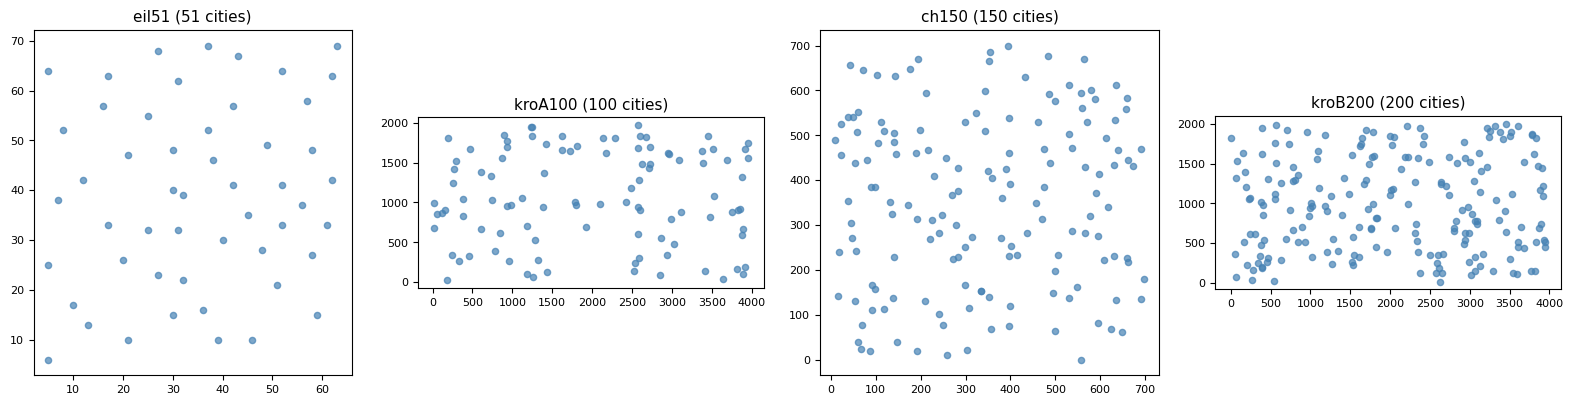

City maps saved.


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
instance_data = [
    ('eil51',   coords51),
    ('kroA100', coords100),
    ('ch150',   coords150),
    ('kroB200', coords200),
]
for ax, (name, coords) in zip(axes, instance_data):
    ax.scatter(coords[:, 0], coords[:, 1], s=20, color='steelblue', alpha=0.7)
    ax.set_title(f'{name} ({len(coords)} cities)', fontsize=11)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

plt.tight_layout()

import os
os.makedirs('paper_tables', exist_ok=True)

plt.savefig('paper_tables/city_maps.pdf', bbox_inches='tight')
plt.show()
print('City maps saved.')